# Self-study try-it activity 14.1: Selecting hyperplanes for two-dimensional data
## Assignment overview:

In this assignment, you will work with two different sets of data points: one exhibiting a linear pattern and the other a non-linear pattern. Your task is to determine which type of kernel performs best for each data set and provide a rationale for your selection.



In [1]:
# import necessary libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import svm
import math
import warnings
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# use the following to plot SVMs
from mlxtend.plotting import plot_decision_regions # on terminal, install: pip install mlxtend

#### Task 1: SVM classifier on a simple data set
Load the two-dimensional data `Case1linear/X.npy` that has 20 rows and two columns, and the corresponding target `Case1linear/y.npy`.

In [5]:
n = 20 # n points in each group
# number used for colour array construction (assumes balanced classes)
X = np.load('data/Case1linear/X.npy')
y = np.load('data/Case1linear/y.npy')

**Plot the two-dimensional points and colour them so that points with the same class have the same colour.**

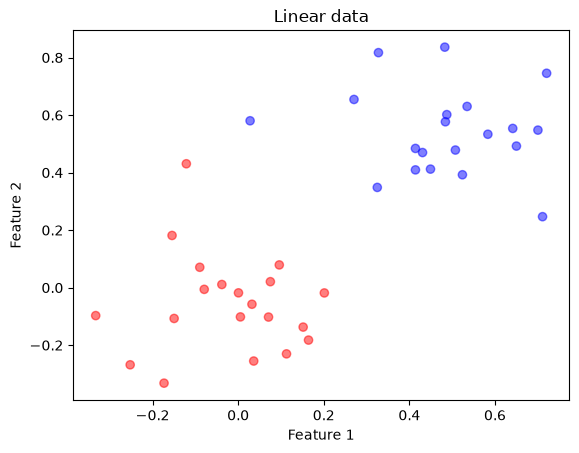

In [7]:
colour = np.concatenate((np.repeat("red", n), np.repeat("blue", n)), axis=0)  # y is split half-half
plt.scatter(X[:, 0], X[:, 1], c=colour, alpha=.5)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Linear data")
plt.show()

**Train an SVM classifier with a linear kernel.**

In [9]:
clf = svm.SVC(kernel = 'linear')
clf.fit(X, y);

**Show the confusion matrix on the training set (since there is no test set, use the given data).**

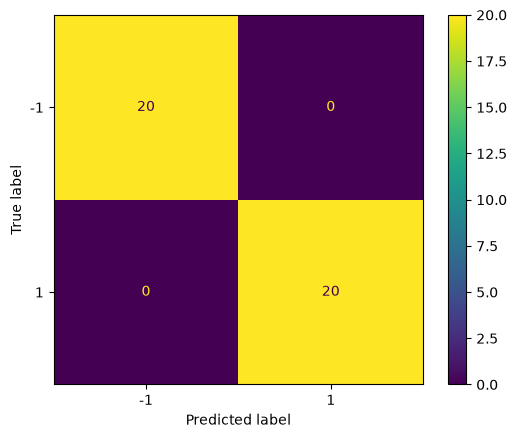

In [11]:
cm = confusion_matrix(y, clf.predict(X))
cmd = ConfusionMatrixDisplay(cm, display_labels=np.unique(y))
cmd.plot();

**Visualise the decision boundary of the kernel by using the `mlxtend` package.**

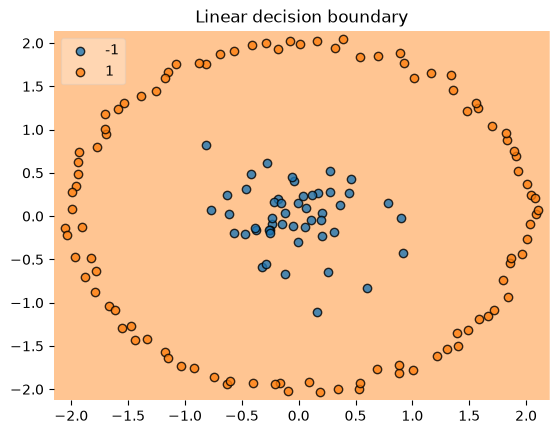

In [20]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    plot_decision_regions(X, y, clf=clf, legend=2, markers= "o", zoom_factor = 10)
    ax=plt.gca()
    plt.title("Linear decision boundary")
    plt.show()

**Relate the visualisation of the decision boundary with the performance observed in the confusion matrix.**

- Answer: ...

#### Task 2: SVM classifier on nested data
Load the two-dimensional data `Case1rings/X.npy` that has 150 rows and two columns and the corresponding target `Case1rings/y.np`.

In [14]:
X = np.load('data/Case1rings/X.npy')
y = np.load('data/Case1rings/y.npy')

**Plot the two-dimensional points and colour them so that points with the same class have the same colour.**

**Train an SVM classifier with a linear kernel.**

In [16]:
clf = svm.SVC(kernel = 'linear')
clf.fit(X, y);

**Show the confusion matrix on the training set.**

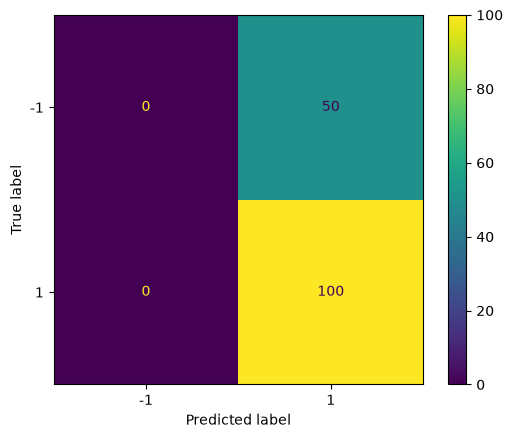

In [17]:
cm = confusion_matrix(y, clf.predict(X))
cmd = ConfusionMatrixDisplay(cm, display_labels=np.unique(y))
cmd.plot();

**Visualise the decision boundary of the kernel by using the `mlxtend` package.**

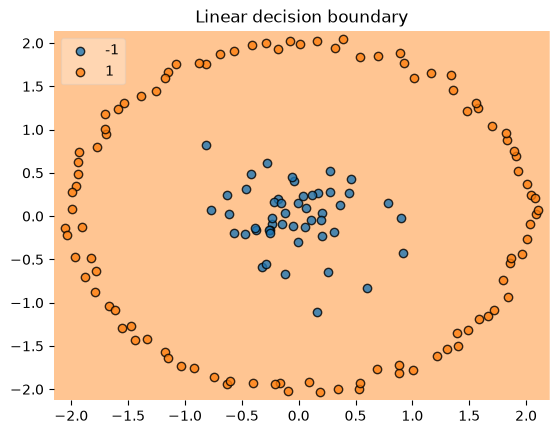

In [19]:
with warnings.catch_warnings(): #Otherwise, the package may throw an error that there is no "boundary" when all samples belong to the same class.
    warnings.simplefilter("ignore")
    plot_decision_regions(X, y, clf=clf, legend=2,  markers= "o", zoom_factor = 10);
    ax=plt.gca();
    plt.title("Linear decision boundary")
    plt.show();

**Train an SVM classifier with a radial kernel.**

In [21]:
clf = svm.SVC(kernel = 'rbf')
clf.fit(X, y)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


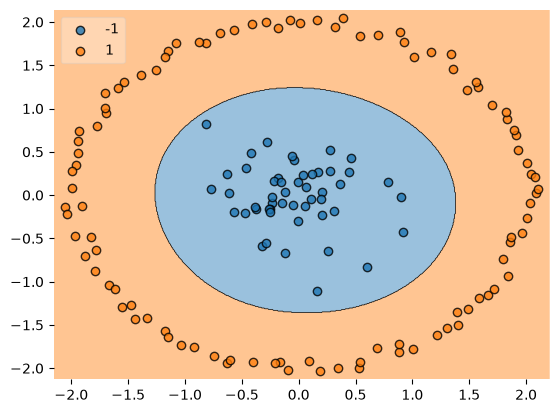

In [22]:
with warnings.catch_warnings(): #Otherwise, the package may throw an error that there is no "boundary" when all samples are classified as '1'
    warnings.simplefilter("ignore")
    plot_decision_regions(X, y, clf=clf, legend=2, markers= "o", zoom_factor = 10);
    ax=plt.gca();
    plt.show();

**Try a polynomial kernel with degree 2.**

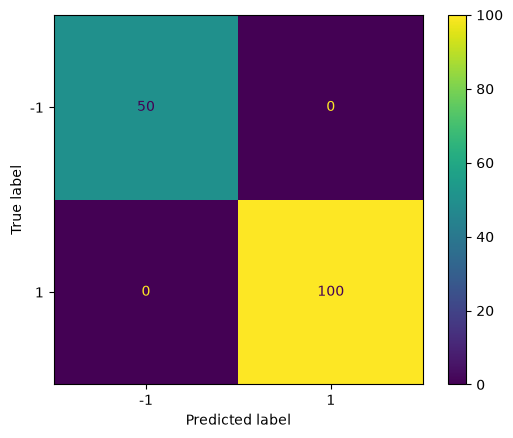

In [23]:
clf = svm.SVC(kernel = 'poly', degree = 2)
clf.fit(X, y)
cm = confusion_matrix(y, clf.predict(X))
cmd = ConfusionMatrixDisplay(cm, display_labels=np.unique(y))
cmd.plot();

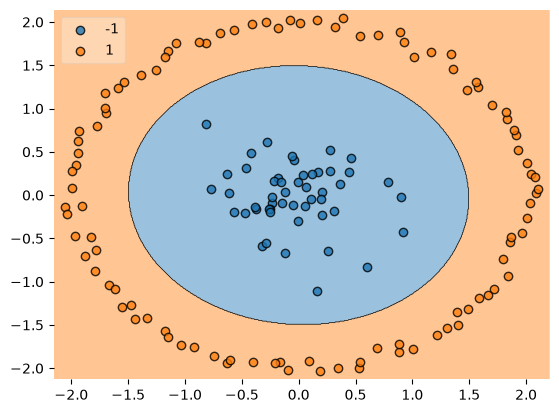

In [24]:
with warnings.catch_warnings(): #Otherwise, the package may throw an error that there is no "boundary" when all samples are classified as '1'
    warnings.simplefilter("ignore")
    plot_decision_regions(X, y, clf=clf, legend=2, markers= "o", zoom_factor = 10);
    ax=plt.gca();
    plt.show();

**Question: Compare the classifiers obtained in this case and discuss why some are better than others.**

- Answer: .....